# Plots de $\epsilon$ con Savitzky–Golay y ventanas solapadas

Réplica de los plots individuales de $\epsilon_{\mathrm{cco}}$ de [`latex_CTW.ipynb`](latex_CTW.ipynb) (celdas 11, 20 y 28) para **NAT**, **9N** y **Charlie Hebdo**, con tres variantes de suavizado/muestreo:

1. **Savitzky–Golay** (ventana 5, polinomio de orden 2) sobre las series $\epsilon$ originales.
2. **Media móvil centrada MA3** (ventanas solapadas post-hoc, paso 1) sobre las series originales.
3. **Ventanas de datos solapadas** ($W=2$ h, paso 1 h): $\epsilon$ recalculado a partir de redes hashtag agregadas en bloques $[t, t+2\,\mathrm{h})$ iniciados cada hora (50 % de solapamiento entre ventanas consecutivas).

**Nota metodológica:** la MA3 suaviza la serie ya calculada sin cambiar cómo se construyen las redes; la variante $W=2$/paso 1 cambia el muestreo de observaciones al construir cada red, manteniendo resolución horaria en el eje temporal.

In [1]:
import datetime as dt
import sys
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from scipy.signal import savgol_filter
from tqdm.auto import tqdm

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from epsilon_sq.fill_missing_epsilon import (
    DATASET_CONFIG,
    compute_epsilon_for_network,
    ensure_prerequisites,
    load_existing_epsilon,
    load_kts,
    save_kts,
    write_results,
)

plt.style.use("seaborn-v0_8-colorblind")

/home/msuarez/Escritorio/self_similarity/main_branch/github/self-similarity-in-social-movements/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constantes temporales (latex_CTW.ipynb, celda 1)
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH = "429624", "437037", "394717"

TIMEZONE = {
    "nat": "America/Argentina/Buenos_Aires",
    "9n": "America/Argentina/Buenos_Aires",
    "ch": "Europe/Paris",
}
CITY_LABEL = {
    "nat": "Buenos Aires",
    "9n": "Buenos Aires",
    "ch": "Paris",
}
X_LABEL_YEAR = {"nat": 2019, "9n": 2019, "ch": 2015}

HORA_CRITICA = {
    "nat": HORA_CRITICA_NAT,
    "9n": HORA_CRITICA_9N,
    "ch": HORA_CRITICA_CH,
}

X_LIM_RELATIVE_CTW = {
    "nat": (-48, 46),
    "9n": (-54, 42),
    "ch": (-48, 36),
}

EPSILON_LABEL = r"$\epsilon_{\mathrm{cco}}$"
MANIFESTATIONS = ["nat", "9n", "ch"]
OVERLAP_HOUR_WINDOW = 2

# Anotaciones visuales idénticas a latex_CTW.ipynb (celdas 11, 20, 28)
PLOT_STYLE = {
    "nat": {
        "orange_spans": [(429620, 429628)],
        "gray_spans": [
            (429580, 429587),
            (429604, 429611),
            (429628, 429635),
            (429652, 429659),
        ],
        "legend_loc": None,
    },
    "9n": {
        "orange_spans": [(437033, 437043), (437059, 437062), (437013, 437018)],
        "gray_spans": [
            (436996, 437003),
            (437020, 437027),
            (437044, 437051),
            (437068, 437075),
        ],
        "legend_loc": None,
    },
    "ch": {
        "orange_spans": [(394716, 394724)],
        "gray_spans": [
            (394680, 394687),
            (394704, 394711),
            (394728, 394735),
            (394752, 394754),
        ],
        "legend_loc": [0.77, 0.2],
    },
}

In [3]:
def hour_to_local(hour, manifestation):
    return dt.datetime.fromtimestamp(int(hour) * 3600, tz=ZoneInfo("UTC")).astimezone(
        ZoneInfo(TIMEZONE[manifestation])
    )


def make_horas_a_fecha_local(manifestation):
    def horas_a_fecha(x_val, pos):
        return hour_to_local(x_val, manifestation).strftime("%d-%b %Hh")

    return horas_a_fecha


def local_xlabel(manifestation):
    return f"Date and hour (local, {CITY_LABEL[manifestation]}, {X_LABEL_YEAR[manifestation]})"


def xlim_relative_ctw(manifestation):
    ctw = int(HORA_CRITICA[manifestation])
    lo, hi = X_LIM_RELATIVE_CTW[manifestation]
    return ctw + lo, ctw + hi


def apply_xlim_relative_ctw(ax, manifestation):
    ax.set_xlim(*xlim_relative_ctw(manifestation))


def find_col(df, candidates):
    for cand in candidates:
        for col in df.columns:
            if col.strip() == cand.strip():
                return col
    return None


def load_epsilon_df(manifestation, variant="results"):
    path = REPO_ROOT / "epsilon_sq" / manifestation / variant / "Epsilon_values.txt"
    df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(
        columns={
            r"$\epsilon_{\ccdf}$": "eps_ccdf",
            r"$\epsilon_{\knn}$": "eps_knn",
            r"$\epsilon_{\cco}$": "eps_cco",
        }
    )
    network_col = find_col(df, ["Network", "network", "NETWORK"])
    cco_col = find_col(df, ["eps_cco", r"$\epsilon_{\cco}$"])
    if network_col is None or cco_col is None:
        raise ValueError(f"Columnas esperadas no encontradas en {path}")
    out = df[[network_col, cco_col]].copy()
    out.columns = ["hour", "eps_cco"]
    out["hour"] = pd.to_numeric(out["hour"], errors="coerce").astype("Int64")
    out["eps_cco"] = pd.to_numeric(out["eps_cco"], errors="coerce")
    return out.dropna().sort_values("hour").reset_index(drop=True)


def savgol_smooth(series, window=5, polyorder=2):
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    if len(values) < window:
        return pd.Series(values, index=series.index)
    if window % 2 == 0:
        window += 1
    smoothed = savgol_filter(values, window_length=window, polyorder=polyorder)
    return pd.Series(smoothed, index=series.index)


def rolling_mean_centrada(series, window=3):
    s = pd.to_numeric(series, errors="coerce")
    return s.rolling(window=window, center=True, min_periods=1).mean()


def apply_decorations(ax, manifestation):
    style = PLOT_STYLE[manifestation]
    ax.axvline(int(HORA_CRITICA[manifestation]), linestyle="-.", color="green")
    for lo, hi in style["orange_spans"]:
        ax.axvspan(lo, hi, color="orange", alpha=0.4)
    for i, (lo, hi) in enumerate(style["gray_spans"]):
        label = "Low activity hours" if i == 0 and manifestation == "nat" else None
        ax.axvspan(lo, hi, color="gray", alpha=0.4, label=label)
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.margins(x=0.01)
    if style["legend_loc"] is not None:
        ax.legend(loc=style["legend_loc"], fontsize=22)


def plot_epsilon_panel(
    manifestation,
    y_values,
    x_hours,
    *,
    label=EPSILON_LABEL,
):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=120)
    ax.plot(x_hours, y_values, marker=None, linewidth=1.8, label=label, c="black")
    apply_decorations(ax, manifestation)
    if manifestation in {"9n", "ch"}:
        ax.set_ylabel("")
    horas_a_fecha = make_horas_a_fecha_local(manifestation)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
    ax.set_xlabel(local_xlabel(manifestation), fontsize=24)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    for tick in ax.get_xticklabels():
        tick.set_rotation(75)
        tick.set_ha("right")
    apply_xlim_relative_ctw(ax, manifestation)
    plt.tight_layout()
    plt.show()
    return fig, ax


def target_hours_for_plot(manifestation):
    lo, hi = xlim_relative_ctw(manifestation)
    return list(range(lo, hi + 1))


def ensure_overlap_series(manifestation, hour_window, *, verbose=True):
    """Completa incrementalmente epsilon_sq/{mov}/w{W} para W h, paso 1 h."""
    datasets_folder = REPO_ROOT / "datasets" / "csvs"
    graphs_folder = REPO_ROOT / "graphs"
    variant = f"w{hour_window}"
    epsilon_dir = REPO_ROOT / "epsilon_sq" / manifestation / variant
    results_dir = epsilon_dir / "results"

    target_hours = target_hours_for_plot(manifestation)
    df_raw = pd.read_csv(datasets_folder / f"{manifestation}.csv")
    available_hours = set(df_raw["hour"].unique())

    # Se necesitan W horas consecutivas de datos para formar [t, t+W)
    hours_in_data = [
        h
        for h in target_hours
        if all((h + step) in available_hours for step in range(hour_window))
    ]

    values, max_rows = load_existing_epsilon(results_dir)
    kts = load_kts(epsilon_dir)
    pending = [h for h in hours_in_data if h not in values]

    if verbose:
        print(
            f"{manifestation.upper()} W={hour_window}: rango plot [{target_hours[0]}, {target_hours[-1]}], "
            f"horas computables={len(hours_in_data)}, existentes={len(values)}, pendientes={len(pending)}"
        )

    iterator = tqdm(pending, desc=f"{manifestation} w{hour_window} fill") if pending else []
    for hour in iterator:
        clave_max = ensure_prerequisites(
            hour,
            manifestation,
            hour_window,
            df_raw,
            epsilon_dir,
            graphs_folder,
            kts,
        )
        if clave_max is None:
            continue
        result = compute_epsilon_for_network(epsilon_dir, hour, clave_max)
        if not all(
            np.isfinite(result[k])
            for k in ("epsilon_ccdf", "epsilon_knn", "epsilon_cco")
        ):
            continue
        values[hour] = {
            "epsilon_ccdf": result["epsilon_ccdf"],
            "epsilon_knn": result["epsilon_knn"],
            "epsilon_cco": result["epsilon_cco"],
        }
        max_rows[hour] = {
            "avg_clustering": result["avg_clustering"],
            "epsilon_max": result["epsilon_max"],
        }

    save_kts(epsilon_dir, kts)
    write_results(results_dir, values, max_rows, sorted(values.keys()))
    return load_epsilon_df(manifestation, variant=f"{variant}/results")


def ensure_overlap_w2_series(manifestation, *, verbose=True):
    """Compatibilidad: W=2 h, paso 1 h."""
    return ensure_overlap_series(manifestation, OVERLAP_HOUR_WINDOW, verbose=verbose)


def ensure_overlap_w3_series(manifestation, *, verbose=True):
    """Completa incrementalmente epsilon_sq/{mov}/w3 para W=3 h, paso 1 h."""
    return ensure_overlap_series(manifestation, 3, verbose=verbose)


## 1. Savitzky–Golay

Filtro Savitzky–Golay con `window_length=5` y `polyorder=2` (mismos parámetros que en `new_plots_review/temporal_plots.py`), aplicado a $\epsilon_{\mathrm{cco}}$ de las series originales en `epsilon_sq/{mov}/results/`.

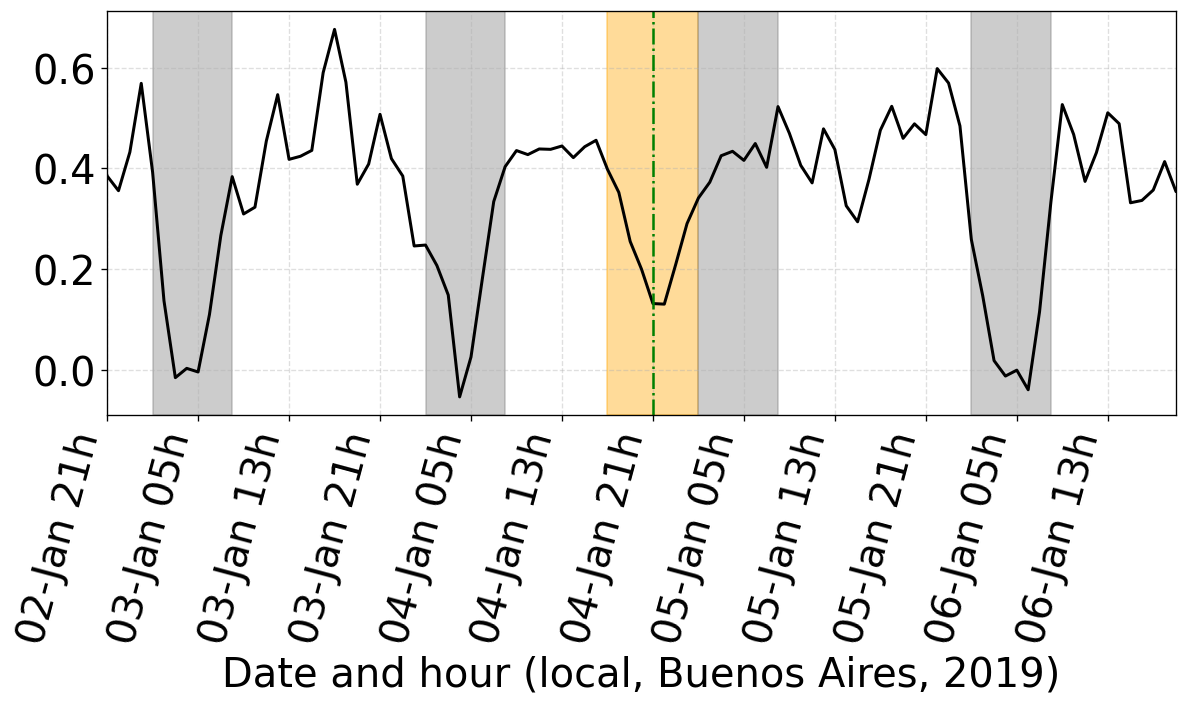

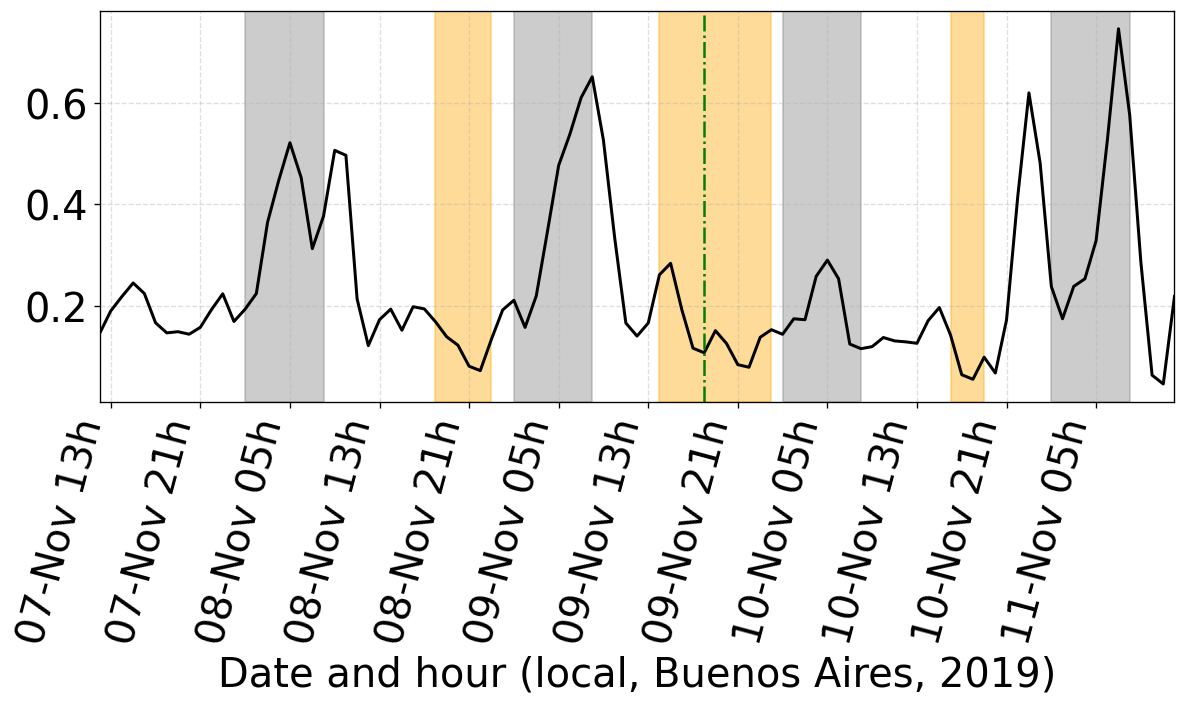

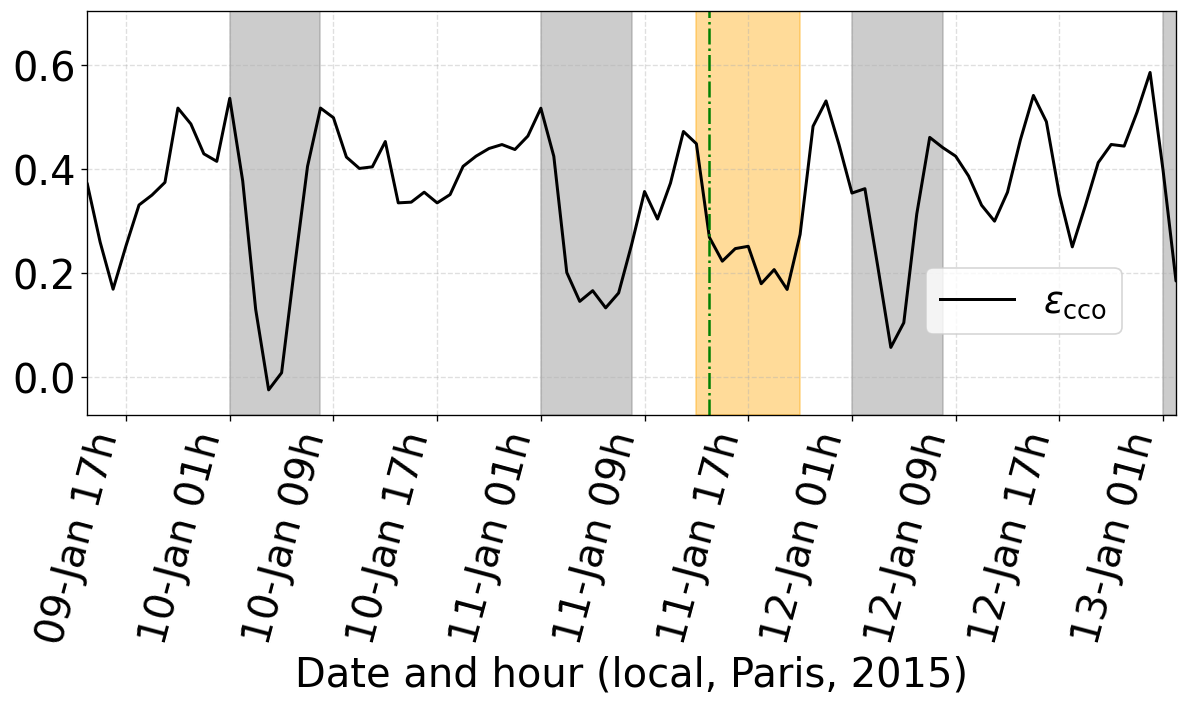

In [4]:
for mov in MANIFESTATIONS:
    df = load_epsilon_df(mov, variant="results")
    y_sg = savgol_smooth(df["eps_cco"], window=5, polyorder=2)
    assert len(y_sg) == len(df)
    assert np.all(np.isfinite(y_sg.to_numpy()))
    plot_epsilon_panel(mov, y_sg, df["hour"], label=EPSILON_LABEL)

## 2. Media móvil centrada solapada (post-hoc)

Media móvil centrada de 3 puntos (`center=True`, `min_periods=1`) sobre las series originales. Ventanas consecutivas comparten 2 de 3 muestras, manteniendo un valor por hora disponible en el eje temporal.

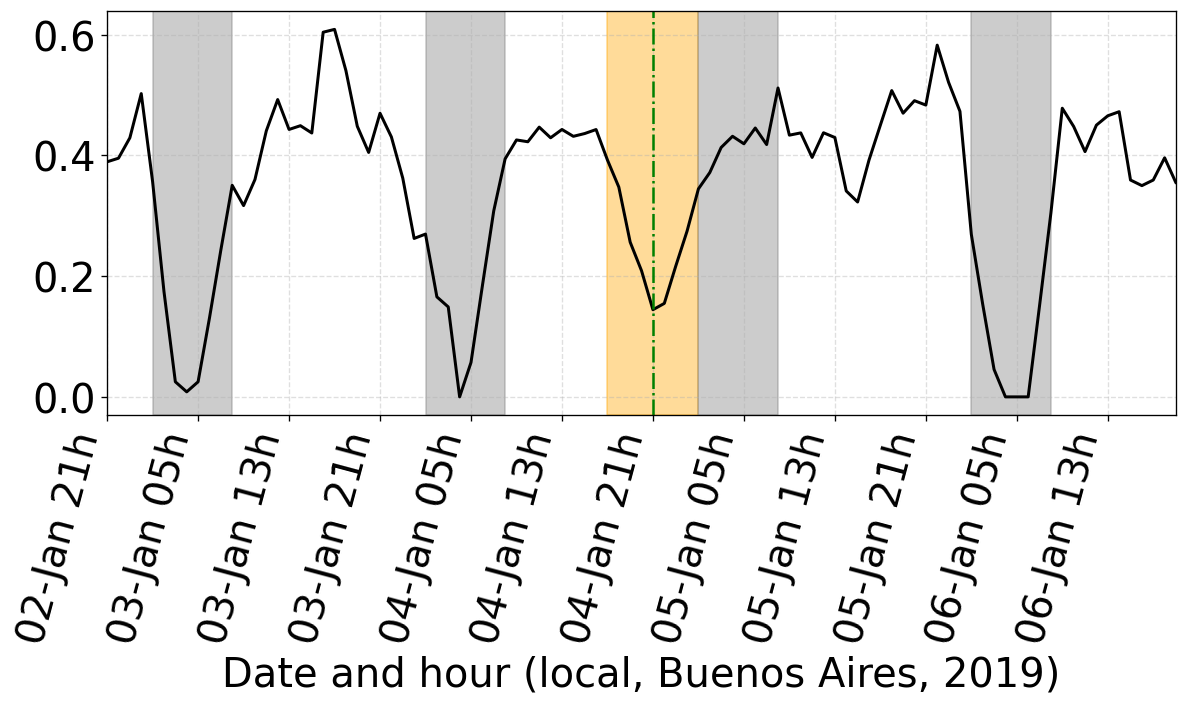

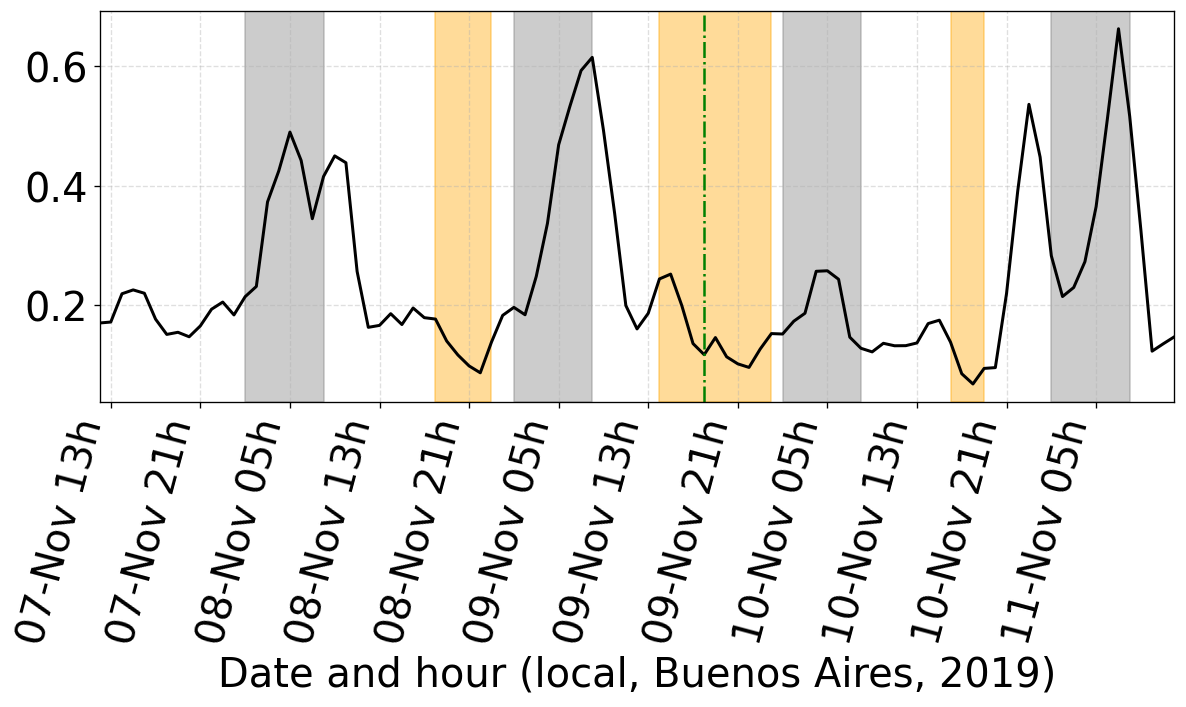

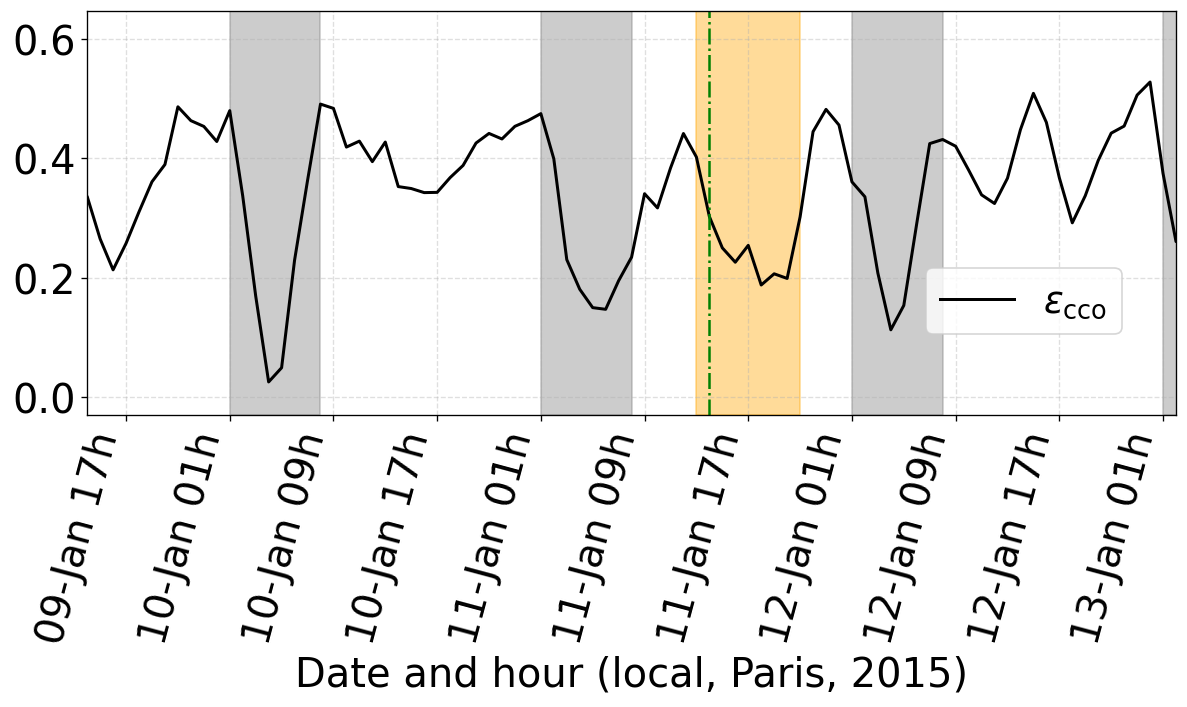

In [5]:
for mov in MANIFESTATIONS:
    df = load_epsilon_df(mov, variant="results")
    y_ma = rolling_mean_centrada(df["eps_cco"], window=3)
    assert len(y_ma) == len(df)
    assert np.all(np.isfinite(y_ma.to_numpy()))
    plot_epsilon_panel(mov, y_ma, df["hour"], label=EPSILON_LABEL)

## 3. Ventanas de datos solapadas ($W=2$ h, paso 1 h)

Cada punto corresponde a $\epsilon_{\mathrm{cco}}$ calculado sobre una red hashtag agregada en el bloque $[t, t+2\,\mathrm{h})$, con inicios $t$ cada hora. Esto introduce un solapamiento real del 50 % entre observaciones consecutivas. Se cargan/completan los resultados en `epsilon_sq/{mov}/w2/results/` y se grafica la serie **sin suavizado adicional**.

NAT W=2: rango plot [429576, 429670], horas computables=95, existentes=94, pendientes=1


nat w2 fill: 100%|██████████| 1/1 [00:00<00:00, 311.73it/s]

9N W=2: rango plot [436983, 437079], horas computables=96, existentes=96, pendientes=0
CH W=2: rango plot [394669, 394753], horas computables=85, existentes=92, pendientes=0
NAT W=2 en rango plot: n=94, pasos={np.int64(1): 92, np.int64(2): 1}


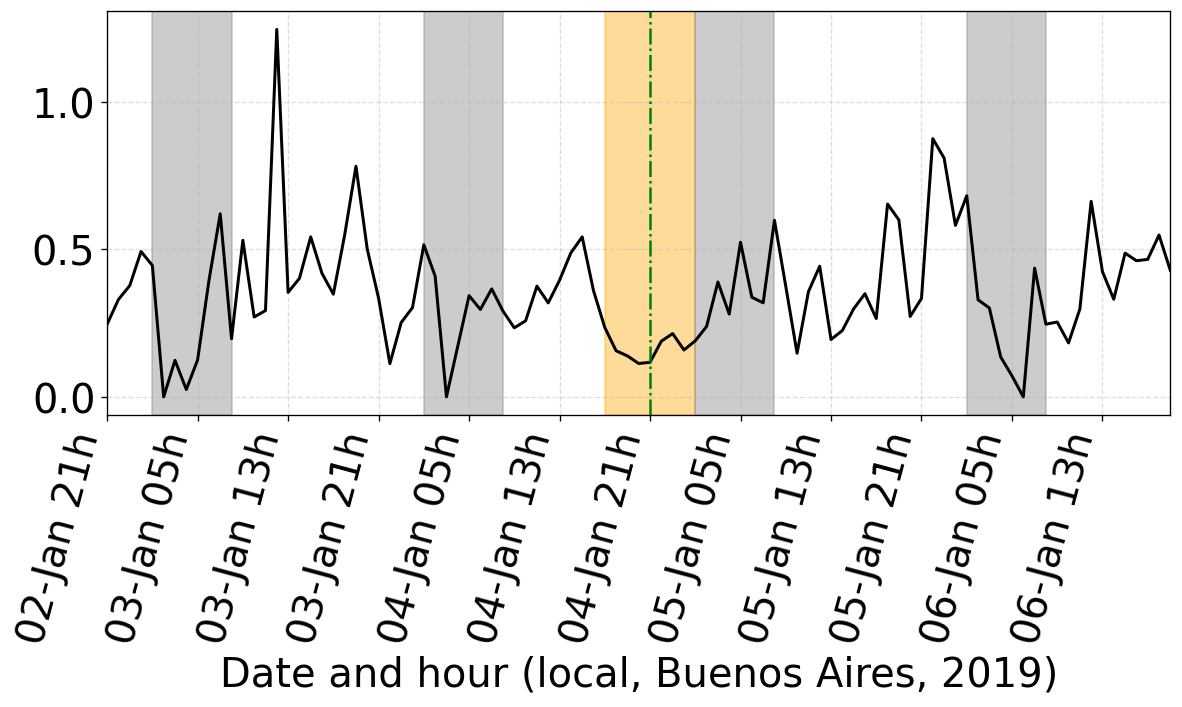

9N W=2 en rango plot: n=96, pasos={np.int64(1): 95}


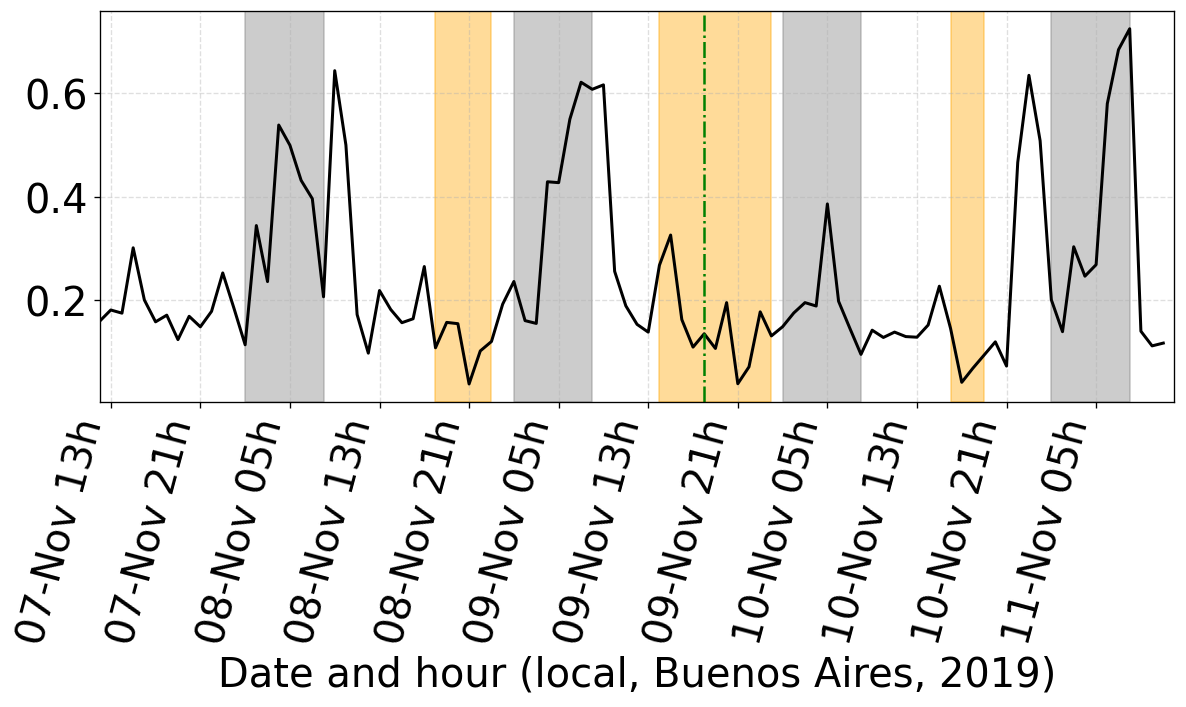

CH W=2 en rango plot: n=85, pasos={np.int64(1): 84}


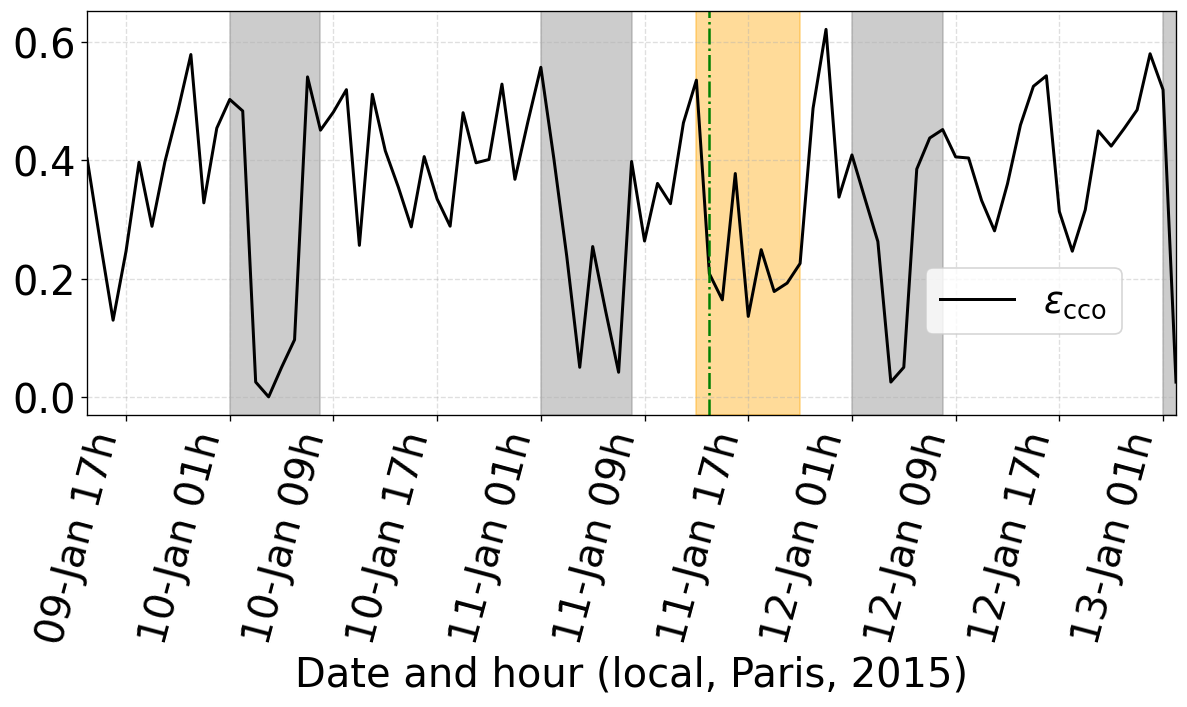

In [6]:
overlap_frames = {}
for mov in MANIFESTATIONS:
    overlap_frames[mov] = ensure_overlap_w2_series(mov)

for mov in MANIFESTATIONS:
    df = overlap_frames[mov]
    lo, hi = xlim_relative_ctw(mov)
    df_plot = df[(df["hour"] >= lo) & (df["hour"] <= hi)].copy()
    steps = df_plot["hour"].diff().dropna().value_counts().sort_index()
    print(f"{mov.upper()} W=2 en rango plot: n={len(df_plot)}, pasos={steps.to_dict()}")
    plot_epsilon_panel(mov, df_plot["eps_cco"], df_plot["hour"], label=EPSILON_LABEL)

In [7]:
# Diagnóstico final
print("=== Resumen de validación ===")
for mov in MANIFESTATIONS:
    df_orig = load_epsilon_df(mov, variant="results")
    df_w2 = overlap_frames[mov]
    lo, hi = xlim_relative_ctw(mov)
    df_w2_range = df_w2[(df_w2["hour"] >= lo) & (df_w2["hour"] <= hi)]
    y_sg = savgol_smooth(df_orig["eps_cco"], window=5, polyorder=2)
    y_ma = rolling_mean_centrada(df_orig["eps_cco"], window=3)
    print(
        f"{mov.upper()}: orig={len(df_orig)}, SG ok={np.all(np.isfinite(y_sg))}, "
        f"MA ok={np.all(np.isfinite(y_ma))}, W2 en rango={len(df_w2_range)}"
    )

=== Resumen de validación ===
NAT: orig=121, SG ok=True, MA ok=True, W2 en rango=94
9N: orig=97, SG ok=True, MA ok=True, W2 en rango=96
CH: orig=189, SG ok=True, MA ok=True, W2 en rango=85


## Comparación conjunta

Grid 3×4: filas = manifestaciones (NAT, 9N, Charlie Hebdo); columnas = media móvil centrada (MA3), Savitzky–Golay (5, 2), ventanas solapadas $W=2$ h (paso 1) y ventanas solapadas $W=3$ h (paso 1).


NAT W=3: rango plot [429576, 429670], horas computables=95, existentes=95, pendientes=0
9N W=3: rango plot [436983, 437079], horas computables=95, existentes=95, pendientes=0
CH W=3: rango plot [394669, 394753], horas computables=85, existentes=92, pendientes=0


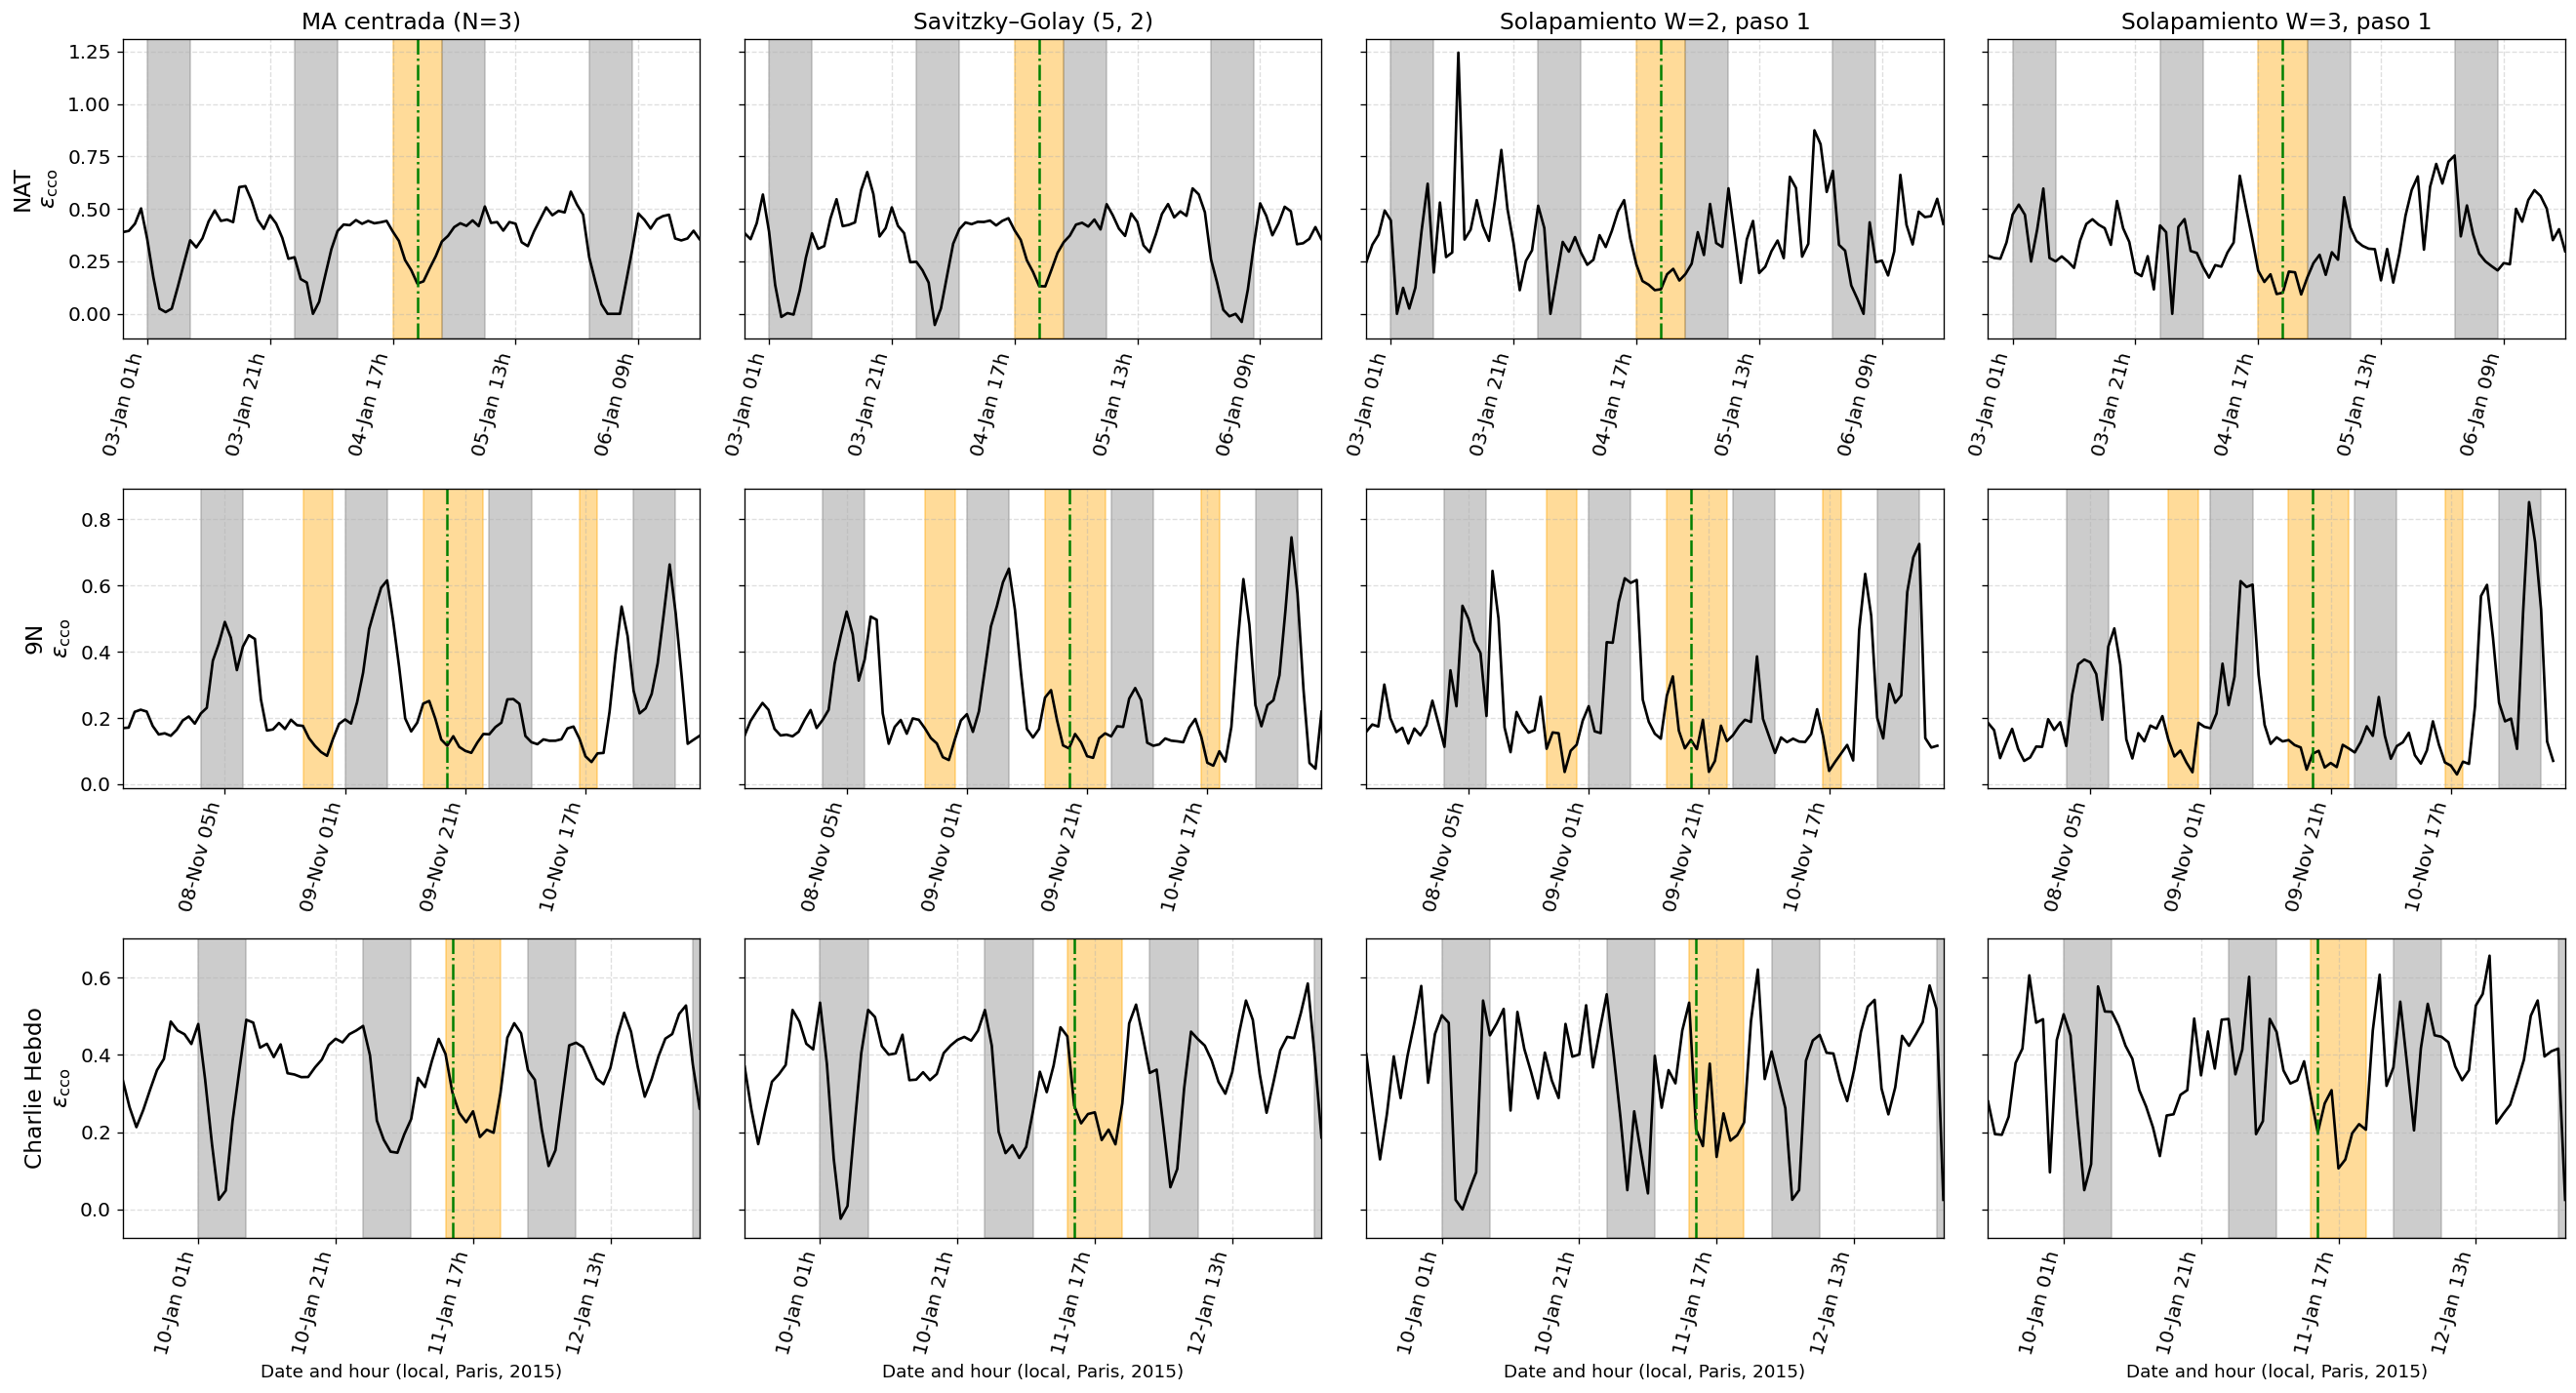

In [8]:
column_specs = [
    ("MA centrada (N=3)", "ma"),
    ("Savitzky–Golay (5, 2)", "sg"),
    ("Solapamiento W=2, paso 1", "overlap_w2"),
    ("Solapamiento W=3, paso 1", "overlap_w3"),
]
row_labels = {"nat": "NAT", "9n": "9N", "ch": "Charlie Hebdo"}

# Asegurar series W=3 (paso 1) para el grid
overlap_w3_frames = {}
for mov in MANIFESTATIONS:
    overlap_w3_frames[mov] = ensure_overlap_w3_series(mov)

fig, axes = plt.subplots(3, 4, figsize=(22, 12), dpi=120, sharex="row", sharey="row")

for i, mov in enumerate(MANIFESTATIONS):
    df_orig = load_epsilon_df(mov, variant="results")
    lo, hi = xlim_relative_ctw(mov)
    df_w2_plot = overlap_frames[mov]
    df_w2_plot = df_w2_plot[(df_w2_plot["hour"] >= lo) & (df_w2_plot["hour"] <= hi)].copy()
    df_w3_plot = overlap_w3_frames[mov]
    df_w3_plot = df_w3_plot[(df_w3_plot["hour"] >= lo) & (df_w3_plot["hour"] <= hi)].copy()

    series_map = {
        "ma": (df_orig["hour"], rolling_mean_centrada(df_orig["eps_cco"], window=3)),
        "sg": (df_orig["hour"], savgol_smooth(df_orig["eps_cco"], window=5, polyorder=2)),
        "overlap_w2": (df_w2_plot["hour"], df_w2_plot["eps_cco"]),
        "overlap_w3": (df_w3_plot["hour"], df_w3_plot["eps_cco"]),
    }

    for j, (col_title, key) in enumerate(column_specs):
        ax = axes[i, j]
        x_hours, y_values = series_map[key]
        ax.plot(x_hours, y_values, marker=None, linewidth=1.6, c="black")

        ax.axvline(int(HORA_CRITICA[mov]), linestyle="-.", color="green")
        for a, b in PLOT_STYLE[mov]["orange_spans"]:
            ax.axvspan(a, b, color="orange", alpha=0.4)
        for a, b in PLOT_STYLE[mov]["gray_spans"]:
            ax.axvspan(a, b, color="gray", alpha=0.4)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.margins(x=0.01)
        apply_xlim_relative_ctw(ax, mov)

        horas_a_fecha = make_horas_a_fecha_local(mov)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        for tick in ax.get_xticklabels():
            tick.set_rotation(75)
            tick.set_ha("right")
        ax.tick_params(axis="both", which="major", labelsize=12)

        if i == 0:
            ax.set_title(col_title, fontsize=14)
        if j == 0:
            ax.set_ylabel(f"{row_labels[mov]}\n{EPSILON_LABEL}", fontsize=14)
        if i == len(MANIFESTATIONS) - 1:
            ax.set_xlabel(local_xlabel(mov), fontsize=11)

plt.tight_layout()
plt.show()
